<a href="https://colab.research.google.com/github/lukezhou10/bte320/blob/main/PandasAssignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Data Analysis assignment (20 points)

You have been given the dataset `travel-times` in a CSV format. This dataset comes from a driver that uses an app to track GPS coordinates as he drives to work and back each day. The app collects the location and elevation data. In total, data for about 200 trips are summarized in this data set.

Load the `travel-times` in a `df` variable using `pandas` and then perform the following:
- print the shape of the dataset **(1 points)**
- print the first 15 rows of the dataset **(1 points)**
- get information for the features (columns) with missing values **(1 points)**
- drop duplicate values (if any) by keeping only the last instance **(1 points)**
- calculate the total number of missing values (if any) on each column **(2 points)**
- create two copies of the dataframe, and then:
    - drop rows with missing values from the 1st copy **(1 points)**
    - drop columns with missing values from the 2nd copy **(1 points)**
- get summary statistics and see the correlation between the numerical columns **(1 points)**
- show rows 11 to 14 **(1 points)**
- create a subset with trips occurred on November 23, 2011 and January 6, 2012 **(2 points)**
- produce a scatterplot between `Distance` and `TotalTime` **(1 points)**
    * Use:
```python
import matplotlib.pyplot as plt
plt.rcParams.update({'font.size': 20, 'figure.figsize': (10, 8)})
```
- produce boxplots for `AvgSpeed` and `AvgMovingSpeed` (use different cells for each) **(2 points)**

In [2]:
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({'font.size': 20, 'figure.figsize': (10, 8)})

In [3]:
df = pd.read_csv("travel-times.csv")

In [5]:
df.shape

(205, 13)

In [6]:
df.head(15)

,Date,StartTime,DayOfWeek,GoingTo,Distance,MaxSpeed,AvgSpeed,AvgMovingSpeed,FuelEconomy,TotalTime,MovingTime,Take407All,Comments
0,1/6/2012,16:37,Friday,Home,51.29,127.4,78.3,84.8,NaN,39.3,36.3,No,NaN
1,1/6/2012,08:20,Friday,GSK,51.63,130.3,81.8,88.9,NaN,37.9,34.9,No,NaN
2,1/4/2012,16:17,Wednesday,Home,51.27,127.4,82.0,85.8,NaN,37.5,35.9,No,NaN
3,1/4/2012,07:53,Wednesday,GSK,49.17,132.3,74.2,82.9,NaN,39.8,35.6,No,NaN
4,1/3/2012,18:57,Tuesday,Home,51.15,136.2,83.4,88.1,NaN,36.8,34.8,No,NaN
5,1/3/2012,07:57,Tuesday,GSK,51.80,135.8,84.5,88.8,NaN,36.8,35.0,No,NaN
6,1/2/2012,17:31,Monday,Home,51.37,123.2,82.9,87.3,-,37.2,35.3,No,NaN
7,1/2/2012,07:34,Monday,GSK,49.01,128.3,77.5,85.9,-,37.9,34.3,No,NaN
8,12/23/2011,08:01,Friday,GSK,52.91,130.3,80.9,88.3,8.89,39.3,36.0,No,NaN
9,12/22/2011,17:19,Thursday,Home,51.17,122.3,70.6,78.1,8.89,43.5,39.3,No,NaN


In [8]:
df.columns[df.isnull().any()]

Index(['FuelEconomy', 'Comments'], dtype='object')

In [9]:
df = df.drop_duplicates(keep='last')
df.shape

(205, 13)

In [10]:
df.isnull().sum()

,0
Date,0
StartTime,0
DayOfWeek,0
GoingTo,0
Distance,0
MaxSpeed,0
AvgSpeed,0
AvgMovingSpeed,0
FuelEconomy,17
TotalTime,0


In [11]:
df1 = df.copy()
df2 = df.copy()


df1 = df1.dropna()


df2 = df2.dropna(axis=1)

print(df1.shape)
print(df2.shape)

(23, 13)
(205, 11)


In [12]:
df.describe()

,Distance,MaxSpeed,AvgSpeed,AvgMovingSpeed,TotalTime,MovingTime
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,50.981512,127.591707,74.477561,81.975610,41.904390,37.871707
std,1.321205,4.128450,11.409816,10.111544,6.849476,4.835072
min,48.320000,112.200000,38.100000,50.300000,28.200000,27.100000
25%,50.650000,124.900000,68.900000,76.600000,38.400000,35.700000
50%,51.140000,127.400000,73.600000,81.400000,41.300000,37.600000
75%,51.630000,129.800000,79.900000,86.000000,44.400000,39.900000
max,60.320000,140.900000,107.700000,112.100000,82.300000,62.400000


In [13]:
df.corr(numeric_only=True)

,Distance,MaxSpeed,AvgSpeed,AvgMovingSpeed,TotalTime,MovingTime
Distance,1.000000,0.145091,-0.006445,0.011874,0.197207,0.197044
MaxSpeed,0.145091,1.000000,0.253869,0.257823,-0.198775,-0.222574
AvgSpeed,-0.006445,0.253869,1.000000,0.872143,-0.877806,-0.835814
AvgMovingSpeed,0.011874,0.257823,0.872143,1.000000,-0.856986,-0.944433
TotalTime,0.197207,-0.198775,-0.877806,-0.856986,1.000000,0.920935
MovingTime,0.197044,-0.222574,-0.835814,-0.944433,0.920935,1.000000


In [14]:
df.iloc[10:14]

,Date,StartTime,DayOfWeek,GoingTo,Distance,MaxSpeed,AvgSpeed,AvgMovingSpeed,FuelEconomy,TotalTime,MovingTime,Take407All,Comments
10,12/22/2011,08:16,Thursday,GSK,49.15,129.4,74.0,81.4,8.89,39.8,36.2,No,NaN
11,12/21/2011,07:45,Wednesday,GSK,51.77,124.8,71.7,78.9,8.89,43.3,39.4,No,NaN
12,12/20/2011,16:05,Tuesday,Home,51.45,130.1,75.2,82.7,8.89,41.1,37.3,No,NaN
13,12/20/2011,06:04,Tuesday,GSK,49.01,119.0,77.4,82.0,8.89,38.0,35.9,No,NaN


In [17]:
df['Date'] = pd.to_datetime(df['Date'])

subset = df[
    (df['Date'] == '2011-11-23') |
    (df['Date'] == '2012-01-06')
]

subset

,Date,StartTime,DayOfWeek,GoingTo,Distance,MaxSpeed,AvgSpeed,AvgMovingSpeed,FuelEconomy,TotalTime,MovingTime,Take407All,Comments
0,2012-01-06,16:37,Friday,Home,51.29,127.4,78.3,84.8,NaN,39.3,36.3,No,NaN
1,2012-01-06,08:20,Friday,GSK,51.63,130.3,81.8,88.9,NaN,37.9,34.9,No,NaN
44,2011-11-23,16:17,Wednesday,Home,60.32,129.4,68.9,74.6,9.3,52.5,48.5,No,NaN
45,2011-11-23,07:22,Wednesday,GSK,51.60,126.4,67.3,73.6,9.3,46.0,42.1,No,NaN


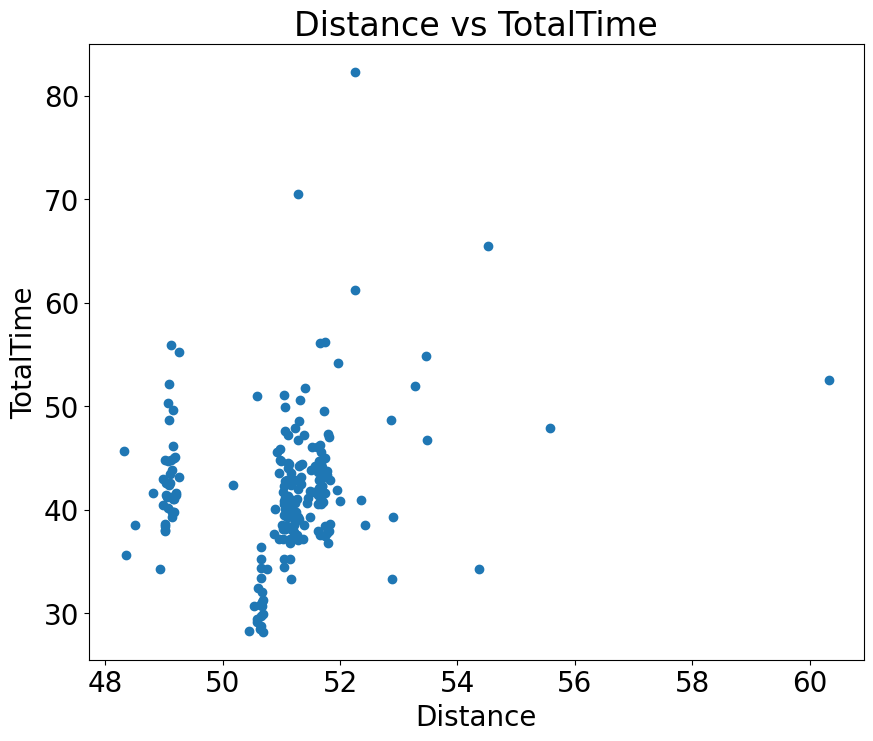

In [18]:
plt.scatter(df['Distance'], df['TotalTime'])
plt.xlabel('Distance')
plt.ylabel('TotalTime')
plt.title('Distance vs TotalTime')
plt.show()

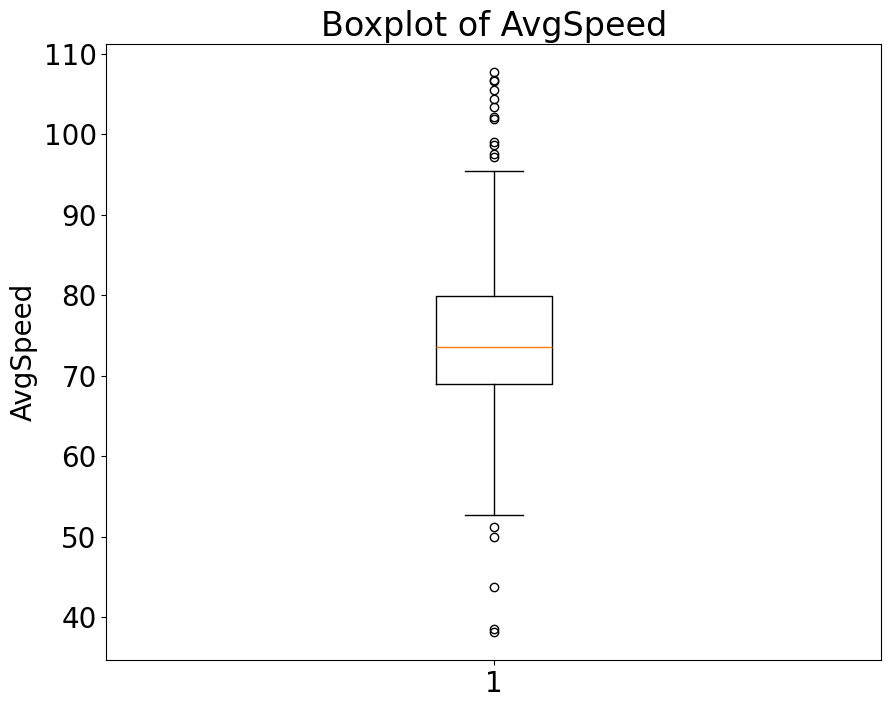

In [19]:
plt.boxplot(df['AvgSpeed'].dropna())
plt.title('Boxplot of AvgSpeed')
plt.ylabel('AvgSpeed')
plt.show()

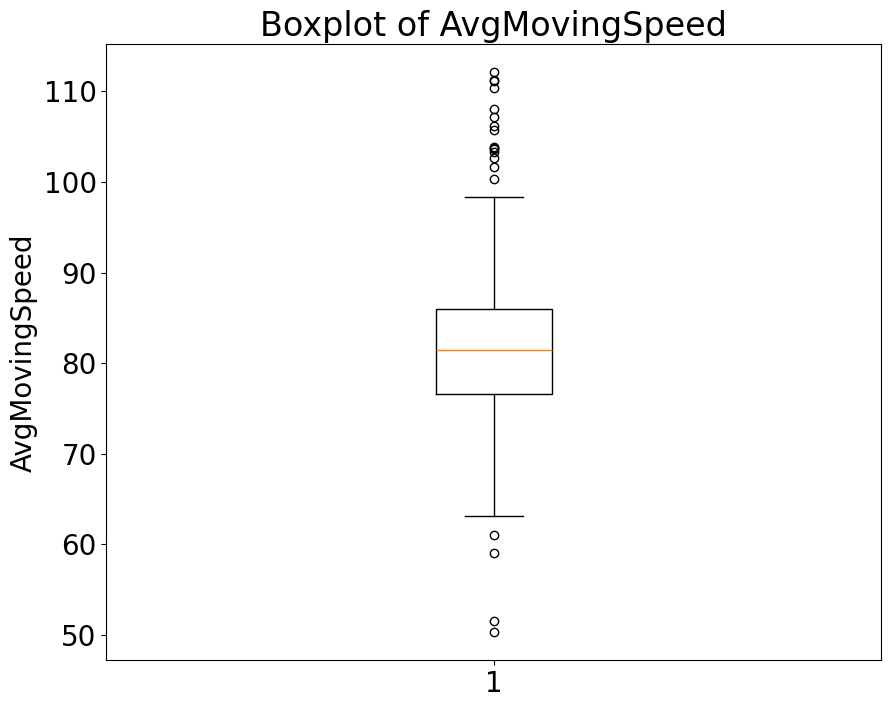

In [20]:
plt.boxplot(df['AvgMovingSpeed'].dropna())
plt.title('Boxplot of AvgMovingSpeed')
plt.ylabel('AvgMovingSpeed')
plt.show()